# Customer Retention Decision System: Predicting Customer Churn and Business Impact

Customer churn is a major challenge for subscription-based businesses, as losing existing customers directly impacts recurring revenue. This project develops a machine learning-based decision support system that predicts customer churn and translates those predictions into actionable business insights.

Beyond predicting which customers are likely to leave, the project estimates the expected revenue at risk, prioritizes high-value customers for retention, and simulates the return on investment (ROI) of different retention strategies. The objective is to demonstrate how machine learning can support data-driven business decisions rather than simply maximize predictive accuracy.


In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot Style
plt.style.use("ggplot")

In [3]:
#Load dataset
df = pd.read_csv("C:/Users/satyb/OneDrive/Desktop/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
#Dataset shape
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 7043
Columns : 21


In [8]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# Statistical info
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [11]:
#Check missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
#Check duplicate records
df.duplicated().sum()

np.int64(0)

In [13]:
#Target variable distribution
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

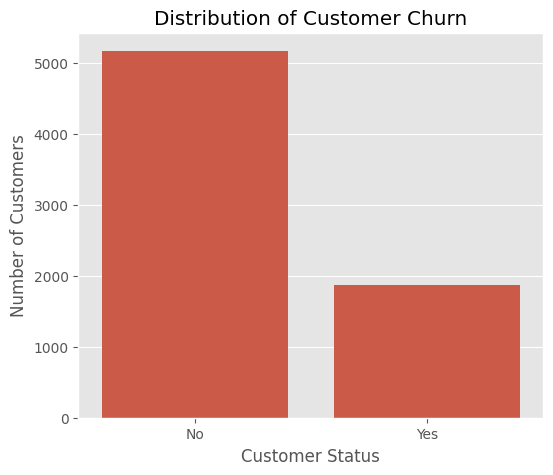

In [15]:
#Visualization
plt.figure(figsize=(6,5))

sns.countplot(data=df , x="Churn")

plt.title("Distribution of Customer Churn")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.show()

In [16]:
# Revenue assumption

In [17]:
active_revenue = df["MonthlyCharges"].sum()

churned_revenue = df[df["Churn"] == "Yes"]["MonthlyCharges"].sum()

print(f"Total Monthly Revenue: ${active_revenue:,.2f}")
print(f"Historical Monthly Revenue Lost Due to Churn: ${churned_revenue:,.2f}")

Total Monthly Revenue: $456,116.60
Historical Monthly Revenue Lost Due to Churn: $139,130.85


In [18]:
#2 DATA CLEANING

#check data types
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [19]:
df["customerID"].head()

0    7590-VHVEG
1    5575-GNVDE
2    3668-QPYBK
3    7795-CFOCW
4    9237-HQITU
Name: customerID, dtype: object

In [20]:
#Converting 'Totalcharges' to numeric datatype (fixing datatype)
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan) 

In [21]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [23]:
# Missing values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [24]:
df.dropna(inplace=True) #drop

In [25]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [26]:
# Duplicate Records
df.duplicated().sum()

np.int64(0)

In [27]:
df.drop_duplicates(inplace=True)

In [28]:
print(df.shape)

(7032, 21)


In [29]:
#3. EXPLORATORY DATA ANALYSIS

#Churn percentage
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


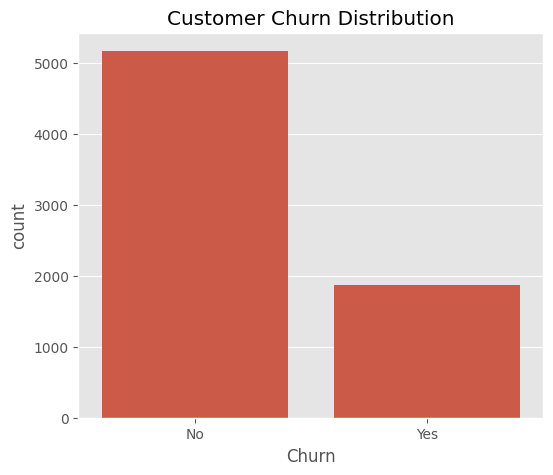

In [30]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x="Churn")

plt.title("Customer Churn Distribution")

plt.show()

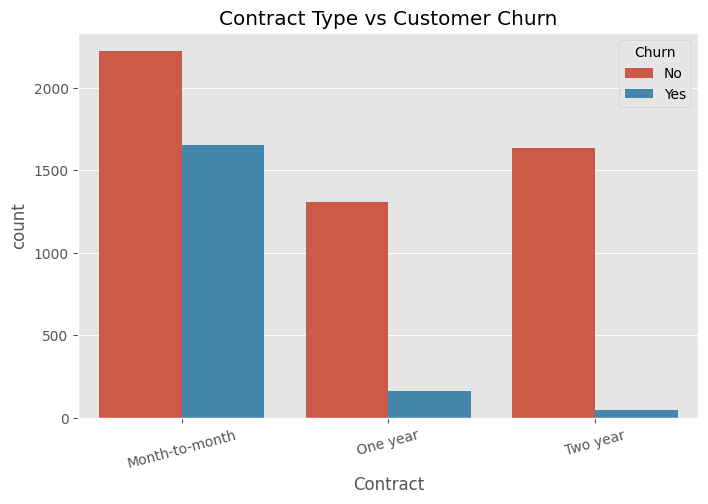

In [31]:
#Contract type analysis
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="Contract",
              hue="Churn")

plt.title("Contract Type vs Customer Churn")

plt.xticks(rotation=15)

plt.show()

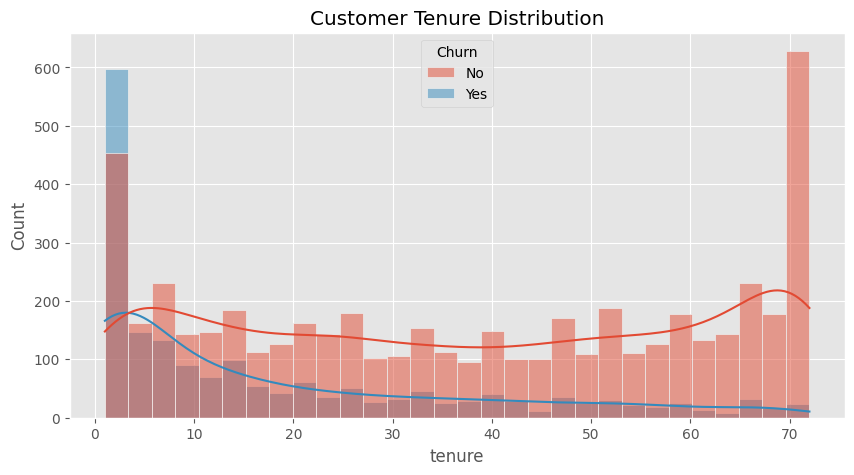

In [32]:
#Tenure analysis
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")

plt.show()

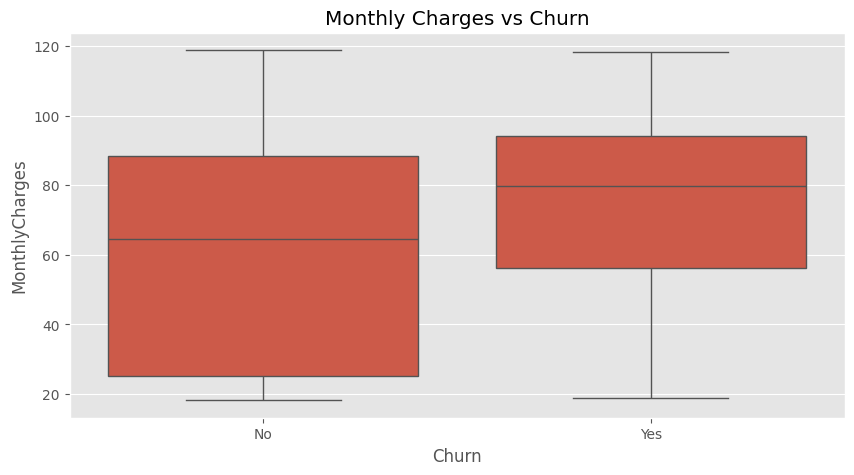

In [33]:
#Monthly charges
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")

plt.show()

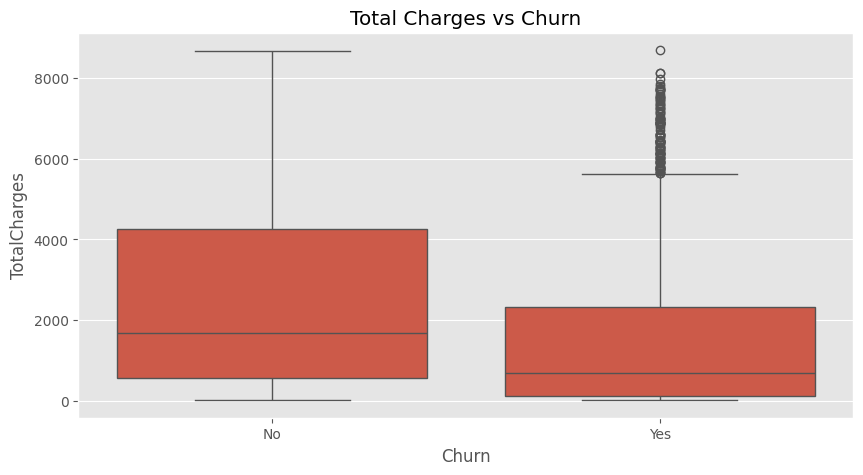

In [34]:
# Total charges
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges vs Churn")

plt.show()

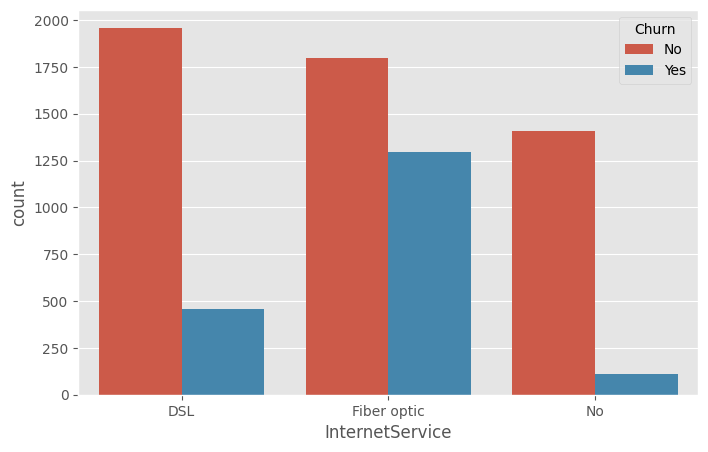

In [35]:
#Internet service
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.show()

In [36]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


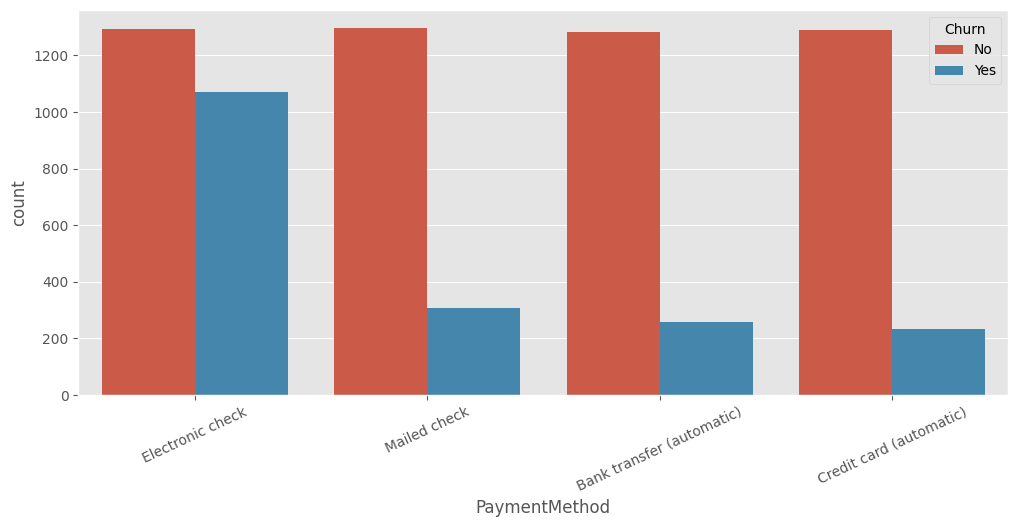

In [37]:
#Payment method
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.xticks(rotation=25)

plt.show()

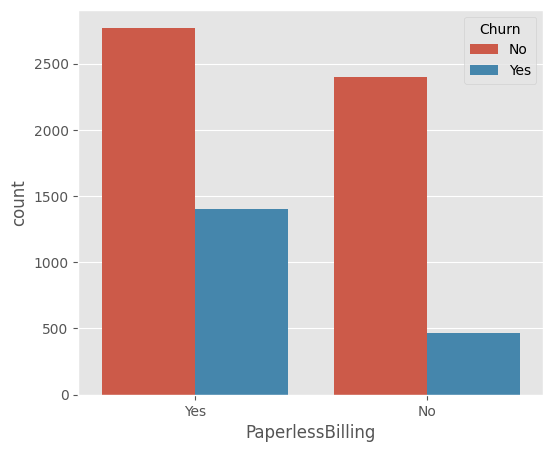

In [38]:
#Paperless Billing
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="PaperlessBilling",
    hue="Churn"
)

plt.show()

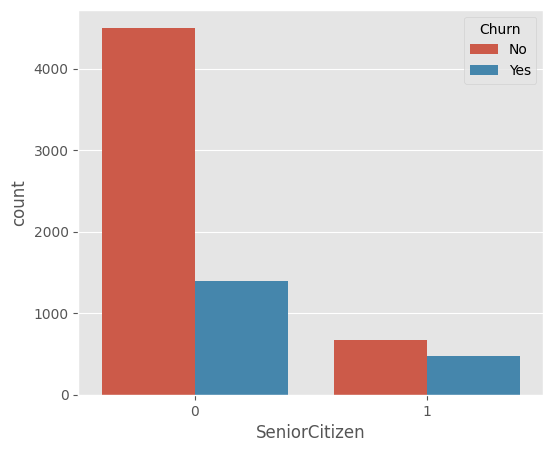

In [39]:
#Senior citizen
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.show()

In [40]:
#Correlation Analysis
df["Churn_Label"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [41]:
numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen",
    "Churn_Label"
]

corr = df[numerical_columns].corr()

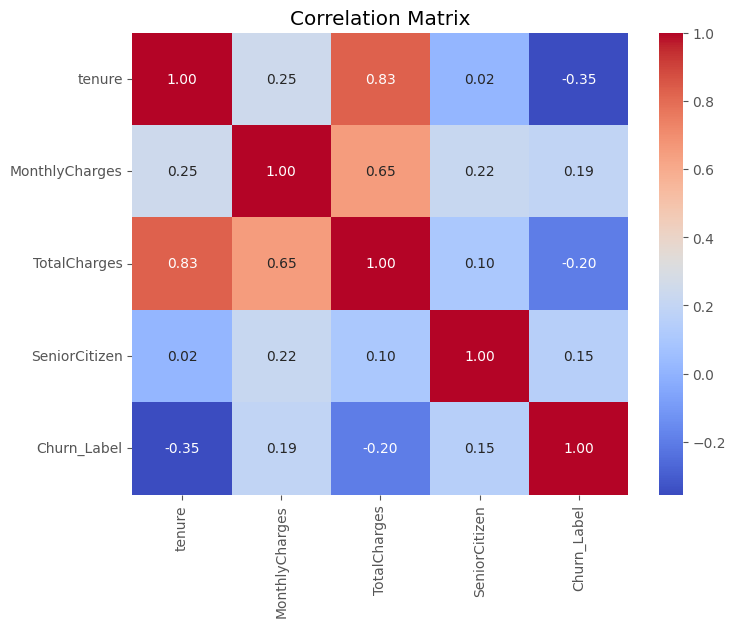

In [42]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

The exploratory analysis identified several patterns associated with customer churn.

## Key Findings
- Month-to-month contracts exhibit the highest churn.
- New customers are significantly more likely to leave.
- Higher monthly charges are associated with increased churn.
- Automatic payment methods appear to improve customer retention.
- Long-term customers demonstrate greater loyalty.

## Business Implications
Rather than applying retention efforts uniformly across all customers, the company should prioritize interventions for customers exhibiting multiple high-risk characteristics.
Targeted retention campaigns are likely to be more cost-effective than broad marketing initiatives.

In [43]:
#4. FEATURE ENGINEERING

# Remove useless columns
df.drop(columns=["customerID"], inplace=True)# Customer ID is only an identifier

In [44]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Label
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,0
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,0
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1


In [45]:
# >> Separate features and targets (x and y)
X = df.drop(columns=["Churn", "Churn_Label"])
y = df["Churn_Label"]

In [46]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60


In [47]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn_Label, Length: 7032, dtype: int64

In [48]:
#Identify numerical and categorical columns
categorical_columns = X.select_dtypes(include="object").columns

numerical_columns = X.select_dtypes(exclude="object").columns

print("Categorical Features:",categorical_columns)

print()

print("Numerical Features: ",numerical_columns)

Categorical Features: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Numerical Features:  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [49]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [50]:
# >> Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [51]:
# >> Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

In [52]:
X_train_scaled[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_test_scaled[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

In [53]:
#5. >> BEST MODEL

!pip install xgboost
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [54]:
from sklearn.metrics import (accuracy_score,precision_score, recall_score,f1_score, roc_auc_score)

In [55]:
def evaluate_model(model, X_train, X_test):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:,1]

    return {

        "Accuracy": accuracy_score(y_test, predictions),

        "Precision": precision_score(y_test, predictions),

        "Recall": recall_score(y_test, predictions),

        "F1": f1_score(y_test, predictions),

        "ROC-AUC": roc_auc_score(y_test, probabilities)

    }

In [56]:
#Logistic regression
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_results = evaluate_model(
    log_model,
    X_train_scaled, 
    X_test_scaled)

log_results

{'Accuracy': 0.8052594171997157,
 'Precision': 0.6515151515151515,
 'Recall': 0.5748663101604278,
 'F1': 0.6107954545454546,
 'ROC-AUC': 0.8360739966143986}

In [57]:
#Random Forest
rf_model = RandomForestClassifier(random_state=42)

rf_results = evaluate_model(
    rf_model,
    X_train,
    X_test
)

rf_results

{'Accuracy': 0.7896233120113717,
 'Precision': 0.6258064516129033,
 'Recall': 0.5187165775401069,
 'F1': 0.5672514619883041,
 'ROC-AUC': 0.8164903116927489}

In [58]:
#XG Boost
xgb_model = XGBClassifier(
     random_state=42,
     eval_metric="logloss"
)


xgb_results = evaluate_model(
    xgb_model,
    X_train,
    X_test
)

xgb_results

{'Accuracy': 0.7711442786069652,
 'Precision': 0.5760233918128655,
 'Recall': 0.5267379679144385,
 'F1': 0.5502793296089385,
 'ROC-AUC': 0.8113899084231069}

In [59]:
#Compare models
comparison = pd.DataFrame({

    "Logistic Regression": log_results,

    "Random Forest": rf_results,

    "XGBoost": xgb_results

})

comparison = comparison.T

comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.805259,0.651515,0.574866,0.610795,0.836074
Random Forest,0.789623,0.625806,0.518717,0.567251,0.816490
XGBoost,0.771144,0.576023,0.526738,0.550279,0.811390


In [60]:
best_model = log_model

In [61]:
#6. >>  PREDICT CHURN PROBABILITY
probability = best_model.predict_proba(X_test)[:,1]

In [62]:
results = X_test.copy()

results["Actual Churn"] = y_test.values
results["Churn Probability"] = probability

In [63]:
results["Expected Revenue at Risk"] = (
    results["Churn Probability"] *
    results["MonthlyCharges"]
)

In [64]:
#Sorting values
results = results.sort_values(
    by="Expected Revenue at Risk",
    ascending=False
)

In [65]:
results

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual Churn,Churn Probability,Expected Revenue at Risk
4586,0,72,118.75,8672.45,False,True,True,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,False,0,1.000000,118.750000
3299,0,68,117.20,8035.95,True,False,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,True,False,True,True,False,False,0,1.000000,117.200000
5137,1,55,116.50,6382.55,True,False,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,False,True,False,True,False,0,1.000000,116.500000
2187,0,71,116.25,8564.75,True,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,True,False,0,1.000000,116.250000
896,0,71,116.10,8310.55,True,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,False,0,1.000000,116.100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3518,0,1,19.45,19.45,True,False,False,True,False,False,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,False,False,False,False,True,0,0.422733,8.222150
2526,0,1,19.40,19.40,True,False,False,True,False,False,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,False,False,False,False,True,1,0.420160,8.151106
1571,0,1,20.05,20.05,True,False,True,True,False,False,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,False,False,False,False,True,0,0.397202,7.963909
4221,0,1,19.30,19.30,True,False,False,True,False,False,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,False,False,True,False,False,0,0.406106,7.837841


In [66]:
#DISPLAYING HIGHEST RISK CUSTOMERS-
results.head(15)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual Churn,Churn Probability,Expected Revenue at Risk
4586,0,72,118.75,8672.45,False,True,True,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,False,0,1.0,118.75
3299,0,68,117.20,8035.95,True,False,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,True,False,True,True,False,False,0,1.0,117.20
5137,1,55,116.50,6382.55,True,False,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,False,True,False,True,False,0,1.0,116.50
2187,0,71,116.25,8564.75,True,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,True,False,0,1.0,116.25
896,0,71,116.10,8310.55,True,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,False,0,1.0,116.10
2885,1,67,116.10,7839.85,True,False,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,True,False,False,0,1.0,116.10
3908,1,60,116.05,6925.90,False,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,False,0,1.0,116.05
4737,0,72,115.50,8312.75,False,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,False,0,1.0,115.50
4170,0,72,115.15,8349.45,True,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,False,False,False,0,1.0,115.15
2515,0,64,115.10,7334.05,False,False,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,False,0,1.0,115.10


# Business Decision Engine

In [67]:
#1. CUSTOMER RISK RANKING

results[
    [
        "MonthlyCharges",
        "Churn Probability",
        "Expected Revenue at Risk"
    ]
].head(10)


,MonthlyCharges,Churn Probability,Expected Revenue at Risk
4586,118.75,1.0,118.75
3299,117.20,1.0,117.20
5137,116.50,1.0,116.50
2187,116.25,1.0,116.25
896,116.10,1.0,116.10
2885,116.10,1.0,116.10
3908,116.05,1.0,116.05
4737,115.50,1.0,115.50
4170,115.15,1.0,115.15
2515,115.10,1.0,115.10


In [68]:
# Customer priority segmentation
results["Priority"] = pd.qcut(
    results["Expected Revenue at Risk"],
    q=3,
    labels=["Low","Medium","High"]
)

In [69]:
results["Priority"].value_counts()

Priority
Low       470
High      469
Medium    468
Name: count, dtype: int64

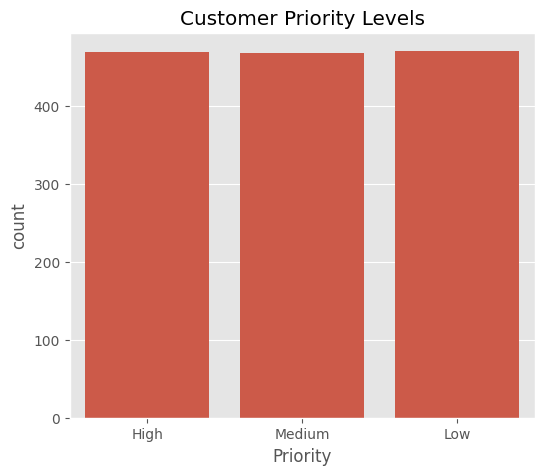

In [70]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=results,
    x="Priority",
    order=["High","Medium","Low"]
)

plt.title("Customer Priority Levels")

plt.show()

In [71]:
#Top 20 customers at risk
top20 = results.sort_values(
    by="Expected Revenue at Risk",
    ascending=False
).head(20)

top20

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual Churn,Churn Probability,Expected Revenue at Risk,Priority
4586,0,72,118.75,8672.45,False,True,True,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,False,0,1.0,118.75,High
3299,0,68,117.20,8035.95,True,False,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,True,False,True,True,False,False,0,1.0,117.20,High
5137,1,55,116.50,6382.55,True,False,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,False,True,False,True,False,0,1.0,116.50,High
2187,0,71,116.25,8564.75,True,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,True,False,0,1.0,116.25,High
896,0,71,116.10,8310.55,True,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,False,0,1.0,116.10,High
2885,1,67,116.10,7839.85,True,False,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,True,False,False,0,1.0,116.10,High
3908,1,60,116.05,6925.90,False,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,False,0,1.0,116.05,High
4737,0,72,115.50,8312.75,False,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,False,0,1.0,115.50,High
4170,0,72,115.15,8349.45,True,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False,False,False,False,0,1.0,115.15,High
2515,0,64,115.10,7334.05,False,False,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,False,0,1.0,115.10,High


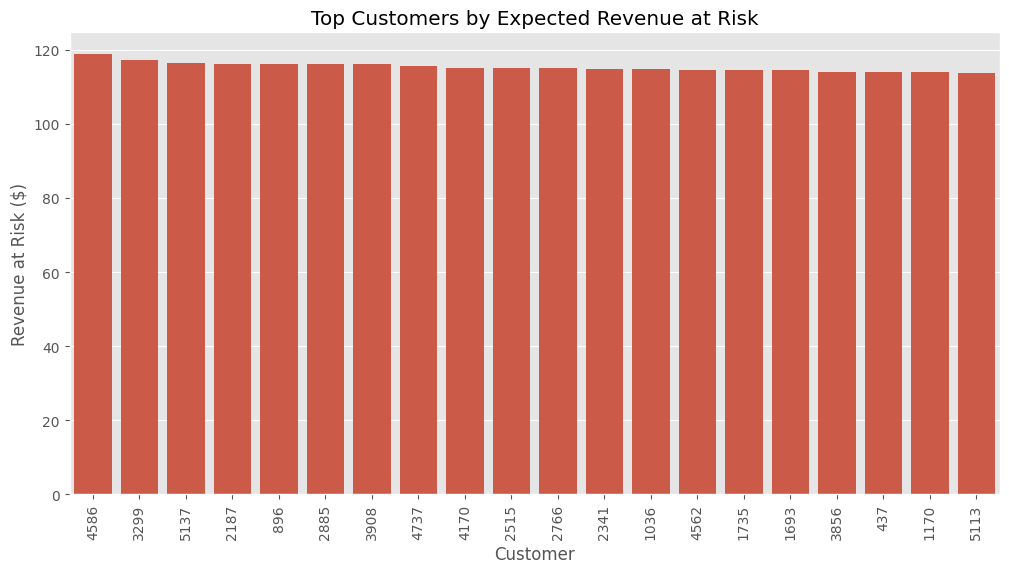

In [72]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top20,
    x=top20.index.astype(str),
    y="Expected Revenue at Risk"
)
plt.xticks(rotation=90)
plt.title("Top Customers by Expected Revenue at Risk")
plt.xlabel("Customer")
plt.ylabel("Revenue at Risk ($)")
plt.show()

### Business Insight

These customers contribute the greatest expected financial risk.

Even if only a small percentage of customers fall into this category, retaining them could preserve a disproportionately large share of monthly recurring revenue.

In [73]:
# Total revenue at risk
total_risk = results["Expected Revenue at Risk"].sum()

print(f"Expected Revenue at Risk : ${total_risk:,.2f}")

Expected Revenue at Risk : $89,652.36


In [74]:
# Revenue by Priority
priority_summary = (
    results
    .groupby("Priority")["Expected Revenue at Risk"]
    .sum()
    .reset_index()
)
priority_summary

,Priority,Expected Revenue at Risk
0,Low,12513.353951
1,Medium,31813.860110
2,High,45325.149986


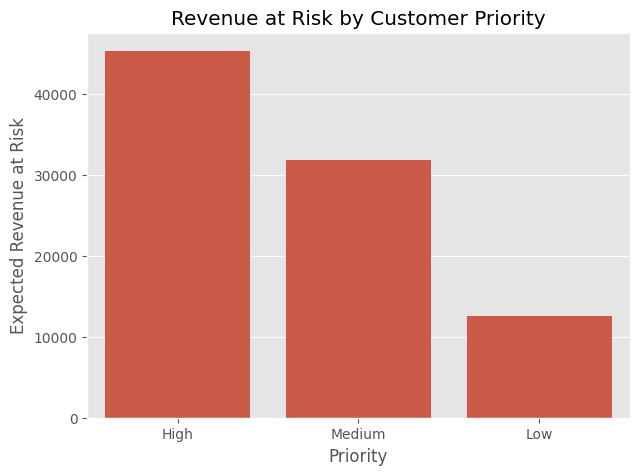

In [75]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=priority_summary,
    x="Priority",
    y="Expected Revenue at Risk",
    order=["High","Medium","Low"]
)

plt.title("Revenue at Risk by Customer Priority")

plt.show()

In [76]:
# High Risk Customer Characteristics

high_priority = results[
    results["Priority"]=="High"
]

In [77]:
high_priority["MonthlyCharges"].describe()

count    469.000000
mean      96.642111
std        9.104273
min       81.750000
25%       89.400000
50%       95.250000
75%      104.750000
max      118.750000
Name: MonthlyCharges, dtype: float64

In [78]:
high_priority["Churn Probability"].mean()

np.float64(0.9999999996626305)

In [79]:
# Executive Dashboard
dashboard = pd.DataFrame({

    "Metric":[

        "Customers Evaluated",

        "Average Churn Probability",

        "Expected Revenue at Risk",

        "High Priority Customers"

    ],

    "Value":[

        len(results),

        round(results["Churn Probability"].mean(),2),

        round(results["Expected Revenue at Risk"].sum(),2),

        (results["Priority"]=="High").sum()

    ]

})

dashboard

,Metric,Value
0,Customers Evaluated,1407.00
1,Average Churn Probability,0.99
2,Expected Revenue at Risk,89652.36
3,High Priority Customers,469.00


# Summary

The machine learning model predicts the probability of customer churn for each customer.
    
Rather than relying solely on churn probability, the analysis combines prediction confidence with customer value to estimate Expected Revenue at Risk.

Customers were segmented into High, Medium, and Low priority groups based on financial impact.

This allows business teams to allocate limited retention resources more effectively.

The dashboard summarizes the scale of customer risk and provides an evidence-based starting point for customer retention planning.

# Retention Campaign Simulation
The machine learning model has identified customers who are at high risk of churning.

The next business decision is determining whether investing in retention campaigns is financially worthwhile.

Three hypothetical retention strategies are evaluated:
- Email Campaign
- Phone Call Campaign
- Discount Offer

Each strategy has different costs and estimated success rates.

The objective is to estimate the financial return generated by each campaign.

In [80]:
#2.  RETENTION STRATEGY


In [81]:
# Select high priority Customers
high_priority = results[
    results["Priority"] == "High"
].copy()

print(f"High Priority Customers: {len(high_priority)}")

High Priority Customers: 469


In [82]:
# Campaign assumptions
campaigns = {

    "Email":{

        "Cost":0.50,

        "SuccessRate":0.12

    },

    "Phone Call":{

        "Cost":8,

        "SuccessRate":0.28

    },

    "Discount Offer":{

        "Cost":20,

        "SuccessRate":0.45

    }

}

In [83]:
# ROI Calculation
def calculate_roi(data, cost, success_rate):

    campaign_cost = len(data) * cost

    expected_revenue_saved = (
        data["Expected Revenue at Risk"].sum()
        * success_rate
    )

    net_profit = (
        expected_revenue_saved
        - campaign_cost
    )

    roi = (
        net_profit
        / campaign_cost
    ) * 100

    return {

        "Campaign Cost":campaign_cost,

        "Revenue Saved":expected_revenue_saved,

        "Net Profit":net_profit,

        "ROI":roi

    }

In [84]:
# Evalaute each strategy
simulation_results = {}

for campaign, values in campaigns.items():

    simulation_results[campaign] = calculate_roi(

        high_priority,

        values["Cost"],

        values["SuccessRate"]

    )

In [85]:
#Result
roi_df = pd.DataFrame(simulation_results).T

roi_df

,Campaign Cost,Revenue Saved,Net Profit,ROI
Email,234.5,5439.017998,5204.517998,2219.410660
Phone Call,3752.0,12691.041996,8939.041996,238.247388
Discount Offer,9380.0,20396.317494,11016.317494,117.444749


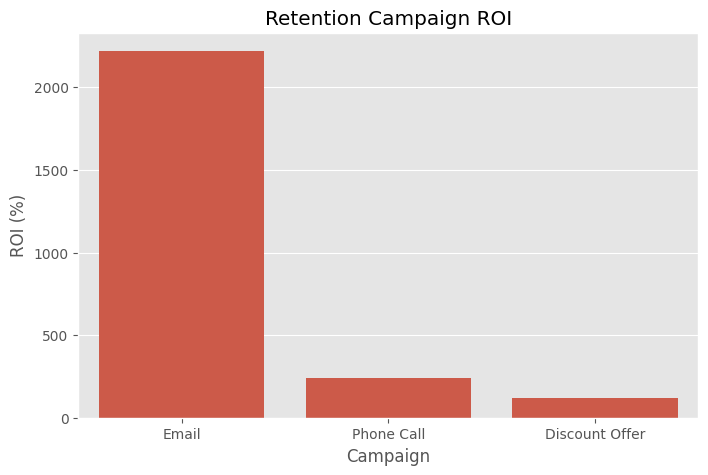

In [86]:
#ROI comparison
plt.figure(figsize=(8,5))

sns.barplot(

    data=roi_df.reset_index(),

    x="index",

    y="ROI"

)

plt.title("Retention Campaign ROI")

plt.xlabel("Campaign")

plt.ylabel("ROI (%)")

plt.show()

### Business Insight

Different retention strategies produce different financial outcomes.

Low-cost campaigns such as email may deliver high ROI despite lower success rates.

Higher-cost strategies such as phone calls or discounts may be more appropriate for premium customers whose expected revenue loss justifies additional investment.

Machine learning enables businesses to allocate retention budgets more efficiently instead of treating every customer equally.

In [87]:
#Determing best campaign
best_campaign = roi_df["ROI"].idxmax()

print(f"Recommended Strategy: {best_campaign}")

Recommended Strategy: Email


In [88]:
#Top customers to contact
customers_to_contact = high_priority.sort_values(

    by="Expected Revenue at Risk",

    ascending=False

).head(50)

customers_to_contact.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual Churn,Churn Probability,Expected Revenue at Risk,Priority
4586,0,72,118.75,8672.45,False,True,True,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,False,0,1.0,118.75,High
3299,0,68,117.20,8035.95,True,False,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,True,False,True,True,False,False,0,1.0,117.20,High
5137,1,55,116.50,6382.55,True,False,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,False,True,False,True,False,0,1.0,116.50,High
2187,0,71,116.25,8564.75,True,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,True,False,0,1.0,116.25,High
896,0,71,116.10,8310.55,True,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,False,0,1.0,116.10,High


In [89]:
#Budget constraint-suppose the business can contact only 50 customers
budget_revenue = customers_to_contact[
    "Expected Revenue at Risk"
].sum()

print(f"Revenue Protected: ${budget_revenue:,.2f}")

Revenue Protected: $5,634.35


In [90]:
#FINAL DASHBOARD
dashboard = pd.DataFrame({

    "Metric":[

        "Customers Evaluated",

        "High Priority Customers",

        "Revenue at Risk",

        "Recommended Campaign",

        "Top Customers Targeted"

    ],

    "Value":[

        len(results),

        len(high_priority),

        round(results["Expected Revenue at Risk"].sum(),2),

        best_campaign,

        len(customers_to_contact)

    ]

})

dashboard

,Metric,Value
0,Customers Evaluated,1407
1,High Priority Customers,469
2,Revenue at Risk,89652.36
3,Recommended Campaign,Email
4,Top Customers Targeted,50


# Executive Summary

This project demonstrates how machine learning can support customer retention decisions in a subscription-based business.

The predictive model estimates the probability of customer churn.

These predictions are combined with customer revenue information to estimate Expected Revenue at Risk.

Customers are prioritized based on their financial impact, allowing the business to focus retention efforts where they are likely to deliver the greatest value.

Finally, multiple retention strategies are evaluated using ROI simulations, providing decision-makers with a framework for selecting cost-effective interventions.

Rather than serving as a standalone prediction model, the system functions as a decision-support tool that helps allocate limited retention resources efficiently.